In [1]:
import pandas as pd
import numpy as np

# Load the diabetes dataset from the data subfolder
df = pd.read_csv('diabetes_prediction_dataset.csv')
df_clean = df.copy()

# Take a look at the data structure
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [2]:
# Always calculate duplicate count from the clean version vs original
initial_rows = len(df)
df_clean = df.drop_duplicates()
final_rows = len(df_clean)

print(f"Removed {initial_rows - final_rows} duplicate rows.")
print(f"Total clean rows: {final_rows}")

Removed 3854 duplicate rows.
Total clean rows: 96146


In [3]:
print("=== Gendere Counts ===")
print(df_clean['gender'].value_counts())

print("\n=== Smoking History Counts ===")
print(df_clean['smoking_history'].value_counts())

=== Gendere Counts ===
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

=== Smoking History Counts ===
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64


In [4]:
df_clean=df_clean[df_clean['gender']!='Other']

In [5]:
smoking_mapping={
    'never':'never',
    'current':'current',
    'former': 'former',
    'not current':'former',
    'ever': 'former',
    'No Info': 'No Info'
}

df_clean['smoking_history']= df_clean['smoking_history'].map(smoking_mapping)

print(df_clean['smoking_history'].value_counts())

smoking_history
never      34395
No Info    32881
former     19655
current     9197
Name: count, dtype: int64


In [6]:
df_clean[['age', 'bmi','HbA1c_level', 'blood_glucose_level']].describe().T

,count,mean,std,min,25%,50%,75%,max
age,96128.0,41.796617,22.463329,0.08,24.0,43.00,59.00,80.00
bmi,96128.0,27.321450,6.767811,10.01,23.4,27.32,29.86,95.69
HbA1c_level,96128.0,5.532633,1.073225,3.50,4.8,5.80,6.20,9.00
blood_glucose_level,96128.0,138.218001,40.911190,80.00,100.0,140.00,159.00,300.00


In [7]:
df_clean=df_clean[(df_clean['age']>=1) & (df_clean['bmi']<=80)]

print(f"Total rows after filtering outliers:{len(df_clean)}")

Total rows after filtering outliers:95209


In [8]:
# Fix gender mapping: Male -> 1, Female -> 0
df_clean['gender'] = df_clean['gender'].replace({'Male': 1, 'Female': 0})

# Re-run encoding for smoking_history
df_encoded = pd.get_dummies(df_clean, columns=['smoking_history'], drop_first=True)

# Preview our clean, fully-numeric dataset
df_encoded.head()

C:\Users\khush\AppData\Local\Temp\ipykernel_7628\2095000977.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['gender'] = df_clean['gender'].replace({'Male': 1, 'Female': 0})


,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_former,smoking_history_never
0,0,80.0,0,1,25.19,6.6,140,0,False,False,True
1,0,54.0,0,0,27.32,6.6,80,0,False,False,False
2,1,28.0,0,0,27.32,5.7,158,0,False,False,True
3,0,36.0,0,0,23.45,5.0,155,0,True,False,False
4,1,76.0,1,1,20.14,4.8,155,0,True,False,False


In [9]:
# Save the cleaned dataset to a new CSV file
df_encoded.to_csv('cleaned_diabetes_data.csv', index=False)

print(" Clean dataset successfully saved as 'cleaned_diabetes_data.csv'!")

 Clean dataset successfully saved as 'cleaned_diabetes_data.csv'!


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_clean=pd.read_csv('cleaned_diabetes_data.csv')
df_clean.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_former,smoking_history_never
0,0,80.0,0,1,25.19,6.6,140,0,False,False,True
1,0,54.0,0,0,27.32,6.6,80,0,False,False,False
2,1,28.0,0,0,27.32,5.7,158,0,False,False,True
3,0,36.0,0,0,23.45,5.0,155,0,True,False,False
4,1,76.0,1,1,20.14,4.8,155,0,True,False,False


C:\Users\khush\AppData\Local\Temp\ipykernel_7628\2149966671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diabetes', data=df_clean, palette='Set2')


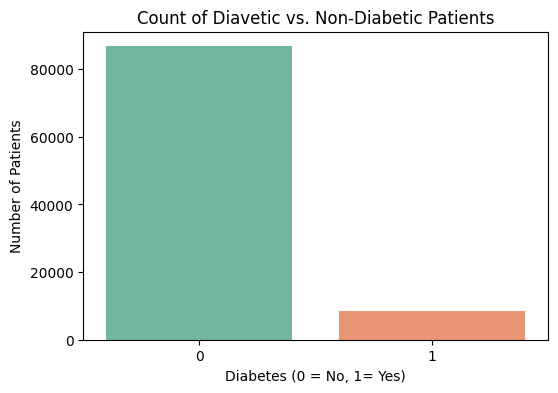

diabetes
0    86730
1     8479
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x='diabetes', data=df_clean, palette='Set2')

plt.title('Count of Diavetic vs. Non-Diabetic Patients')
plt.xlabel('Diabetes (0 = No, 1= Yes)')
plt.ylabel('Number of Patients')

plt.show()
print(df_clean['diabetes'].value_counts())

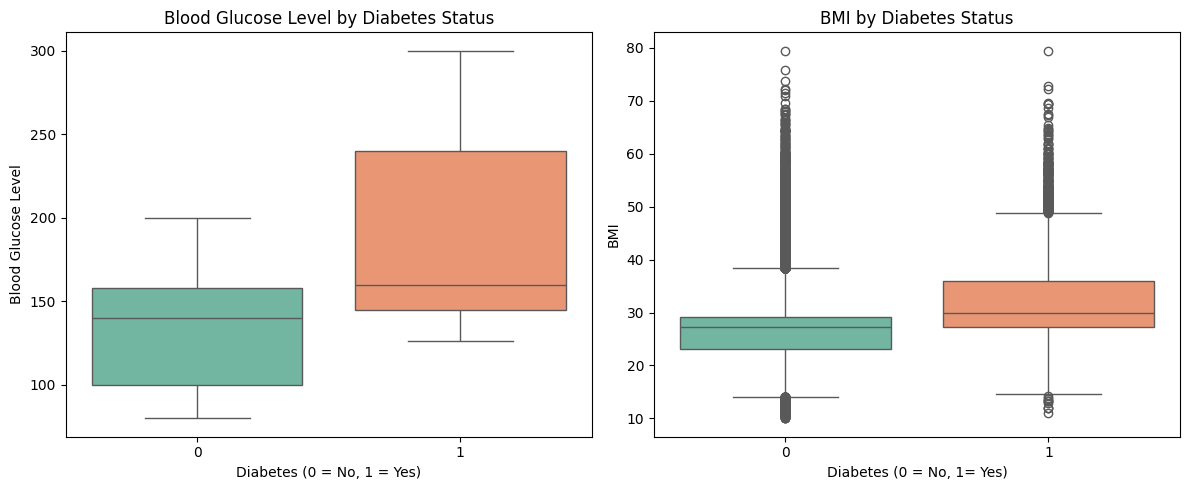

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.boxplot(
    x="diabetes",
    y="blood_glucose_level",
    data=df_clean,
    hue="diabetes",
    legend=False,
    palette="Set2",
)
plt.title("Blood Glucose Level by Diabetes Status")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Blood Glucose Level")

plt.subplot(1,2,2)
sns.boxplot(
    x="diabetes",
    y="bmi",
    data=df_clean,
    hue="diabetes",
    legend=False,
    palette="Set2",
)
plt.title("BMI by Diabetes Status")
plt.xlabel("Diabetes (0 = No, 1= Yes)")
plt.ylabel("BMI")

plt.tight_layout()
plt.show()

Updated dataset saved! Total rows remaining: 95103


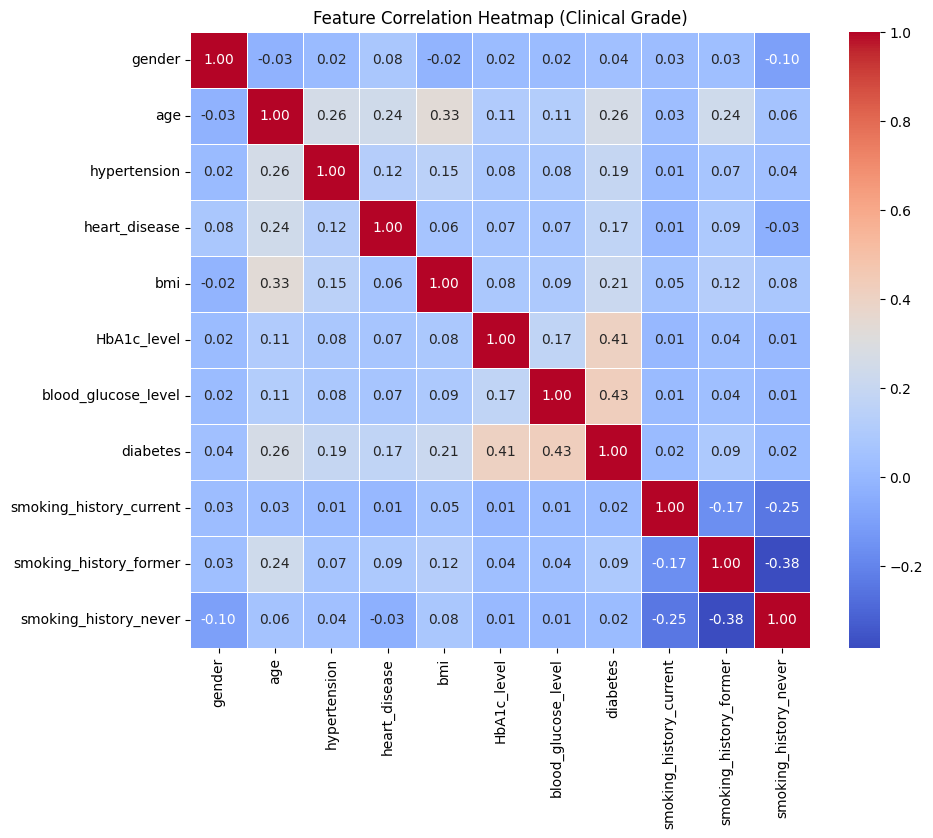

In [13]:
# 1. Filter out extreme BMI outliers (> 60)
df_clean = df_clean[df_clean["bmi"] <= 60]

# 2. Save the updated clean dataset
df_clean.to_csv("cleaned_diabetes_data.csv", index=False)
print(f"Updated dataset saved! Total rows remaining: {len(df_clean)}")

# 3. Generate the Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Calculate correlation matrix
corr = df_clean.corr()

# Plot heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Feature Correlation Heatmap (Clinical Grade)")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_clean.drop(columns=['diabetes'])
y = df_clean['diabetes']

# 80% train, 20% test, preserving the 91:9 class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (76082, 10), X_test: (19021, 10)


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train with class-weight balancing
model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate on unseen 20% test data
y_pred = model.predict(X_test)
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     17332
           1       0.78      0.73      0.75      1689

    accuracy                           0.96     19021
   macro avg       0.88      0.85      0.87     19021
weighted avg       0.96      0.96      0.96     19021

=== Confusion Matrix ===
[[16991   341]
 [  461  1228]]


In [16]:
import joblib

# Export trained model for FastAPI
joblib.dump(model, "diabetes_model.joblib")
print("Saved model as diabetes_model.joblib")

Saved model as diabetes_model.joblib


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd

# Calculate imbalance ratio for boosting algorithms (~91/9 = ~10)
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=imbalance_ratio, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(scale_pos_weight=imbalance_ratio, random_state=42, verbose=-1)
}

comparison_records = []

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else None
    
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    
    comparison_records.append({
        "Model": name,
        "Diabetic Recall (Class 1)": round(recall, 4),
        "Diabetic F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4) if isinstance(auc, float) else auc
    })

# Add existing Random Forest result for direct comparison
df_results = pd.DataFrame(comparison_records)
print(df_results)

                 Model  Diabetic Recall (Class 1)  Diabetic F1-Score  ROC-AUC
0  Logistic Regression                     0.8804             0.5836   0.9613
1              XGBoost                     0.8780             0.6575   0.9756
2             LightGBM                     0.9070             0.6413   0.9775


In [18]:
import joblib

# Export LightGBM as the updated production model
joblib.dump(models["LightGBM"], "diabetes_model.joblib")
print("Saved LightGBM model to diabetes_model.joblib")

Saved LightGBM model to diabetes_model.joblib
